In [9]:
import pandas as pd
import numpy as np

# 1. Load the data properly as an Excel file
# Make sure 'openpyxl' is installed in your environment (run: !pip install openpyxl)
df = pd.read_excel('bank.xlsx')

# 2. Preview the raw Excel data
print("--- Excel Data Preview ---")
print(df.head())

# 3. Check for standard missing values (NaN)
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

# 4. Check for 'unknown' placeholders text columns
print("\n--- 'Unknown' Counts Per Column ---")
for col in df.columns:
    if df[col].dtype == 'object':
        unknown_count = (df[col] == 'unknown').sum()
        if unknown_count > 0:
            print(f"{col}: {unknown_count} values")

# 5. Check and remove exact duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\n--- Duplicates found: {duplicate_count} ---")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed successfully.")

# 6. SAVE IT STRICLY AS AN EXCEL FILE (.xlsx)
df.to_excel('bank_cleaned.xlsx', index=False)

print("\nSuccess! The data is clean and saved as 'bank_cleaned.xlsx'")

--- Excel Data Preview ---
  age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"
0  30;"unemployed";"married";"primary";"no";1787;...                                                                                                  
1  33;"services";"married";"secondary";"no";4789;...                                                                                                  
2  35;"management";"single";"tertiary";"no";1350;...                                                                                                  
3  30;"management";"married";"tertiary";"no";1476...                                                                                                  
4  59;"blue-collar";"married";"secondary";"no";0;...                                                                                                  

--- Missing Values Per Column ---
age;"job";"marital";"education";

In [30]:
# --- Step 1 & 2: Load, Auto-Split Columns, and Summary Statistics ---
import pandas as pd
import numpy as np

# 1. Load your file
df = pd.read_excel('bank_cleaned.xlsx')

# 2. AUTO-FIX: If all data is trapped in 1 column, break it down into proper separate columns
if len(df.columns) == 1:
    single_col_name = df.columns[0]
    # Extract clean column headers by splitting on semicolons
    proper_headers = [col.replace('"', '').strip() for col in single_col_name.split(';')]
    
    # Split the row data by semicolons into separate columns
    df = df[single_col_name].astype(str).str.split(';', expand=True)
    df.columns = proper_headers

# 3. Clean up any remaining double quotes or spaces from all text cells
for col in df.columns:
    df[col] = df[col].astype(str).str.replace('"', '').str.strip()

# 4. Convert numerical columns from text strings back to numbers so math functions work
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 5. Display the successful structure breakdown
print(f"Success! Dataset split into: {df.shape[0]} rows, {df.shape[1]} proper columns\n")
print("--- Cleaned Column List ---")
print(df.columns.tolist())

print("\n--- Numerical Columns Summary ---")
display(df.describe())

print("\n--- Categorical Columns Summary ---")
display(df.describe(include=['O']))

Success! Dataset split into: 4521 rows, 17 proper columns

--- Cleaned Column List ---
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

--- Numerical Columns Summary ---


,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000



--- Categorical Columns Summary ---


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,4521,4521,4521,4521,4521,4521,4521,4521,4521,4521
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,yes,no,cellular,may,unknown,no
freq,969,2797,2306,4445,2559,3830,2896,1398,3705,4000


In [31]:
# --- Step 3: Analyze the Target Variable ('y') ---

# Calculate raw counts and percentages
target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

print("--- Subscription Breakdown (Target Variable 'y') ---")
for outcome in target_counts.index:
    print(f"'{outcome}': {target_counts[outcome]} clients ({target_pct[outcome]:.2f}%)")

--- Subscription Breakdown (Target Variable 'y') ---
'no': 4000 clients (88.48%)
'yes': 521 clients (11.52%)


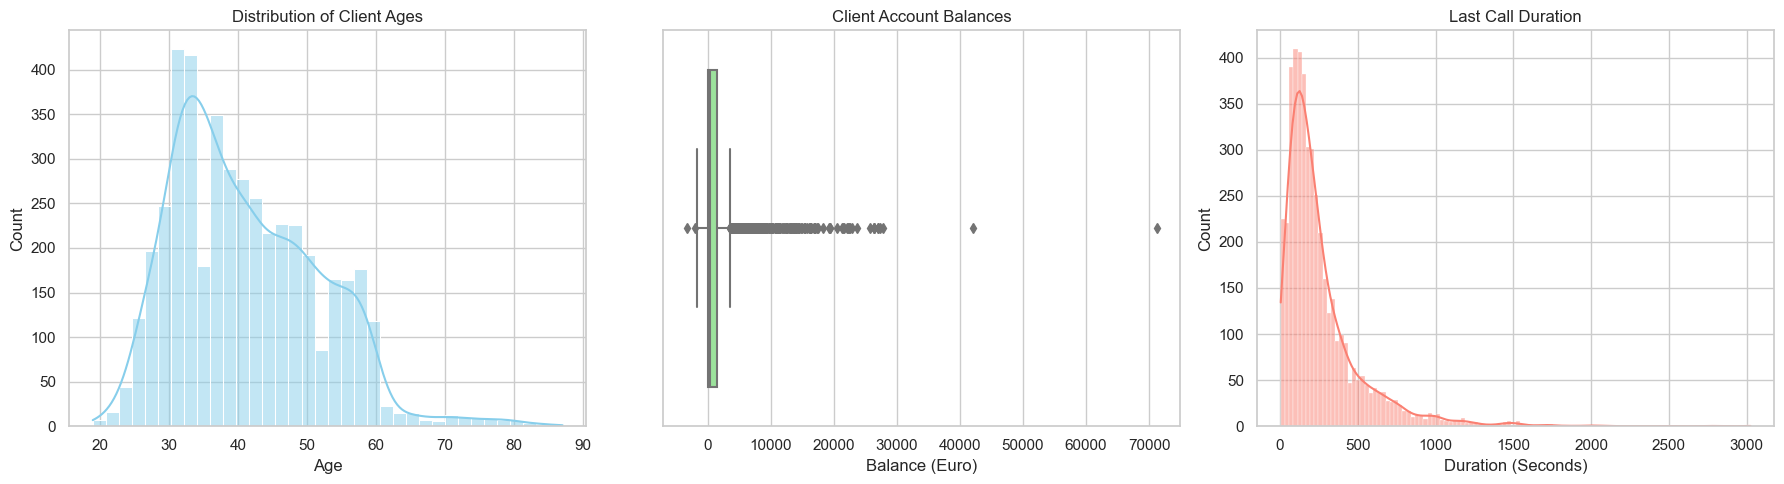

In [32]:
# --- Step 4: Univariate Analysis (Numerical Columns) ---
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a 1 row, 3 columns grid for the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of Age
sns.histplot(data=df, x='age', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Client Ages')
axes[0].set_xlabel('Age')

# 2. Distribution of Balance (Boxplot helper to find extreme spreads)
sns.boxplot(data=df, x='balance', ax=axes[1], color='lightgreen')
axes[1].set_title('Client Account Balances')
axes[1].set_xlabel('Balance (Euro)')

# 3. Last Call Duration Distribution
sns.histplot(data=df, x='duration', kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Last Call Duration')
axes[2].set_xlabel('Duration (Seconds)')

plt.tight_layout()
plt.show()


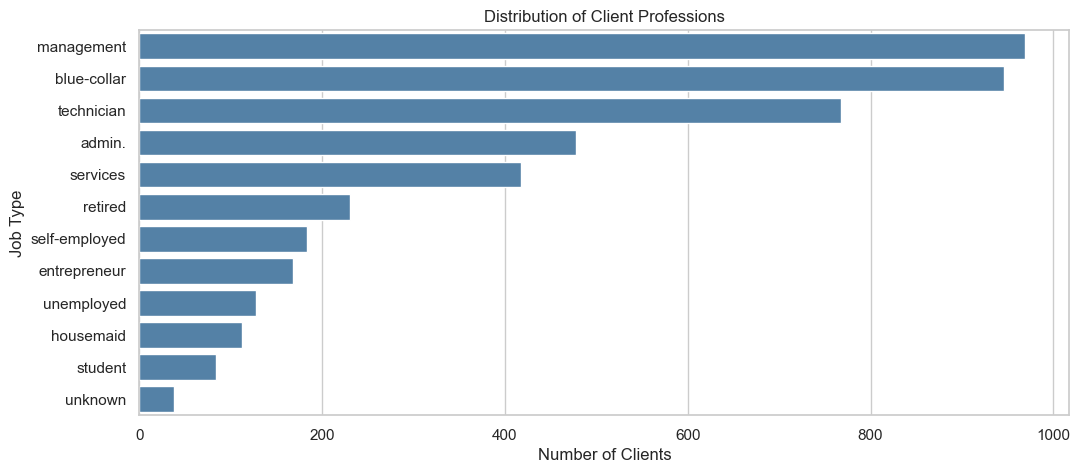

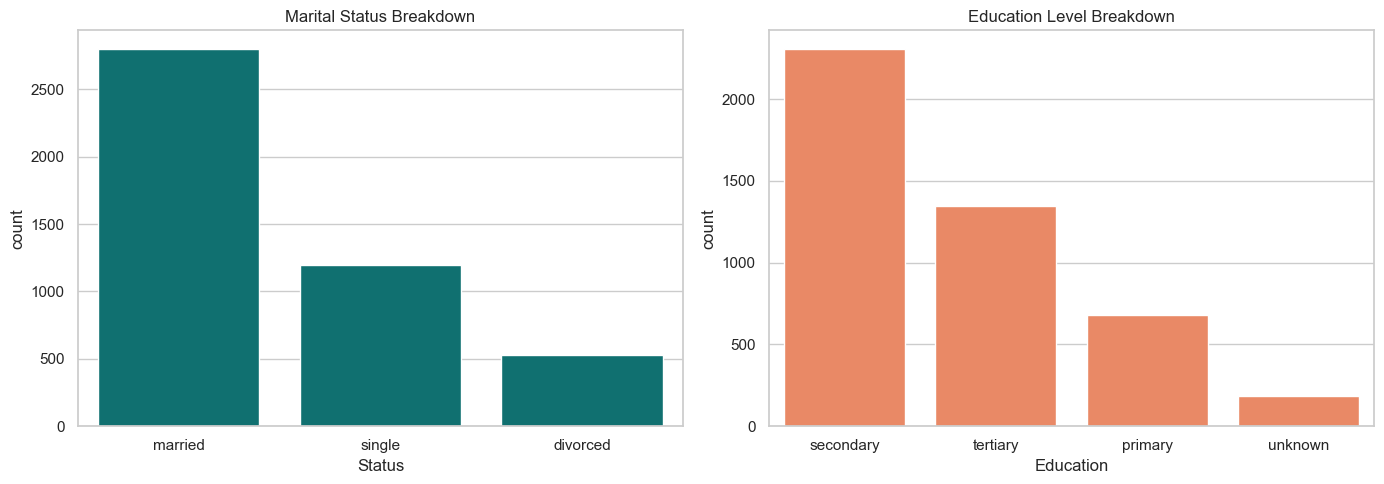

In [33]:
# --- Step 5: Univariate Analysis (Demographics) ---

# 1. Job Distribution (Sorted from highest to lowest frequency)
plt.figure(figsize=(12, 5))
job_order = df['job'].value_counts().index
sns.countplot(data=df, y='job', order=job_order, color='steelblue')
plt.title('Distribution of Client Professions')
plt.xlabel('Number of Clients')
plt.ylabel('Job Type')
plt.show()

# 2. Marital Status & Education Breakdown Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='marital', order=df['marital'].value_counts().index, ax=axes[0], color='teal')
axes[0].set_title('Marital Status Breakdown')
axes[0].set_xlabel('Status')

sns.countplot(data=df, x='education', order=df['education'].value_counts().index, ax=axes[1], color='coral')
axes[1].set_title('Education Level Breakdown')
axes[1].set_xlabel('Education')

plt.tight_layout()
plt.show()

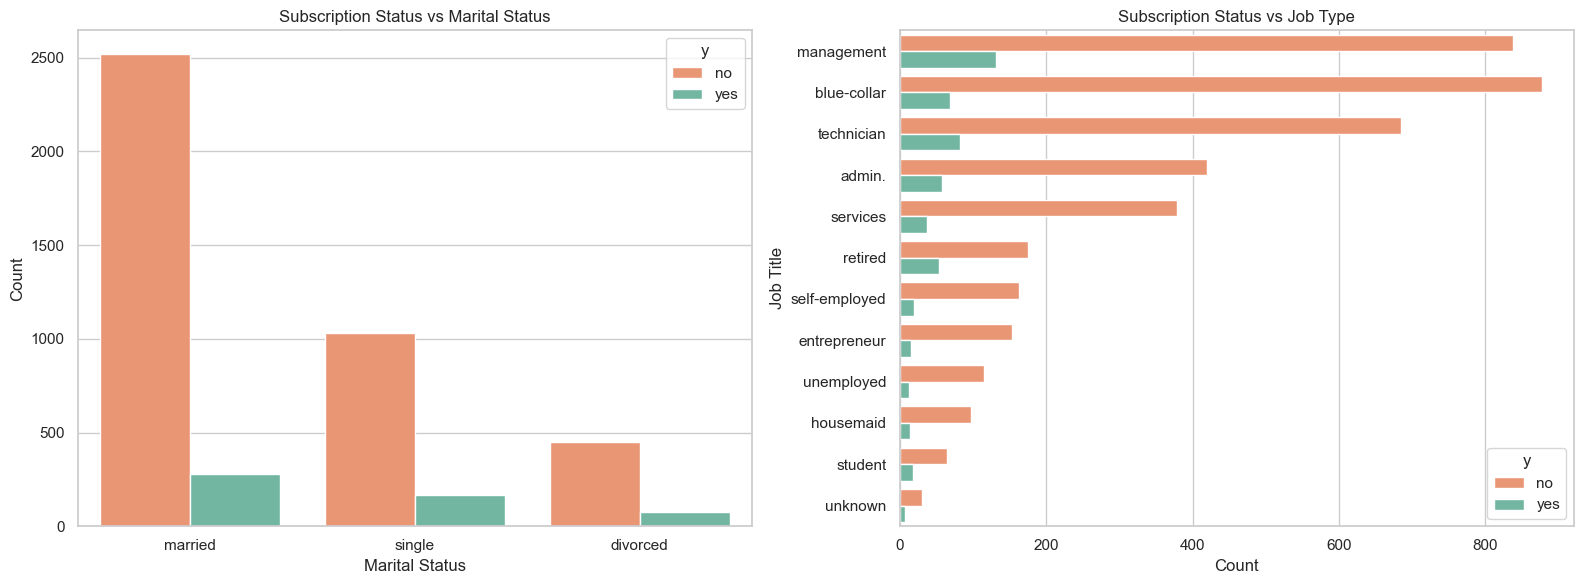

In [34]:
# --- Step 6: Bivariate Analysis (Demographics vs. Target Success) ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Explicit, safe hex color array for ['no', 'yes'] outcomes
safe_colors = ['#fc8d62', '#66c2a5']

# 1. Subscription success based on Marital Status
sns.countplot(data=df, x='marital', hue='y', ax=axes[0], palette=safe_colors)
axes[0].set_title('Subscription Status vs Marital Status')
axes[0].set_xlabel('Marital Status')
axes[0].set_ylabel('Count')

# 2. Subscription success based on Job Type
sns.countplot(data=df, y='job', hue='y', order=df['job'].value_counts().index, ax=axes[1], palette=safe_colors)
axes[1].set_title('Subscription Status vs Job Type')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Job Title')

plt.tight_layout()
plt.show()

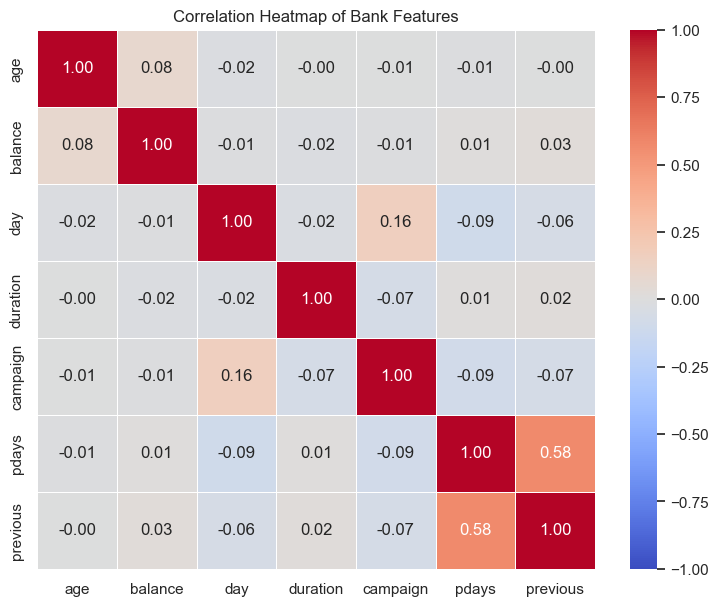

In [35]:
# --- Step 7: Numerical Feature Correlations ---

# Isolate purely columns containing numbers
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Generate the calculation matrix
corr_matrix = numeric_df.corr()

# Build and render the Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Bank Features')
plt.show()

In [37]:
# --- Step 8: Stratified Train-Test Split (With Built-in Data Reload) ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Reload the clean Excel file to make sure 'df' exists in memory
df = pd.read_excel('bank_cleaned.xlsx')

# 2. Re-apply the column split fix just in case the data is packed in 1 column
if len(df.columns) == 1:
    single_col_name = df.columns[0]
    proper_headers = [col.replace('"', '').strip() for col in single_col_name.split(';')]
    df = df[single_col_name].astype(str).str.split(';', expand=True)
    df.columns = proper_headers

# 3. Clean quotes and clean column names
df.columns = df.columns.str.replace('"', '').str.strip()
for col in df.columns:
    df[col] = df[col].astype(str).str.replace('"', '').str.strip()

# 4. Separate your features (X) from your imbalanced target variable (y)
X = df.drop(columns=['y'])
y = df['y']

# 5. Perform the Stratified Split (preserves the 88% / 11% class imbalance perfectly)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,       # 20% for testing, 80% for training
    stratify=y,           # Keeps the exact same class imbalance ratio in both sets
    random_state=42       # Keeps the shuffle reproducible
)

# 6. Print verification metrics
print("--- Stratified Imbalance Split Verification ---")
print(f"Original Dataset Proportions:\n{y.value_counts(normalize=True) * 100}\n")
print(f"Training Set Proportions:\n{y_train.value_counts(normalize=True) * 100}\n")
print(f"Testing Set Proportions:\n{y_test.value_counts(normalize=True) * 100}\n")

print(f"Training shapes: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Testing shapes:  X_test: {X_test.shape}, y_test: {y_test.shape}")

--- Stratified Imbalance Split Verification ---
Original Dataset Proportions:
no     88.476001
yes    11.523999
Name: y, dtype: float64

Training Set Proportions:
no     88.46792
yes    11.53208
Name: y, dtype: float64

Testing Set Proportions:
no     88.508287
yes    11.491713
Name: y, dtype: float64

Training shapes: X_train: (3616, 16), y_train: (3616,)
Testing shapes:  X_test: (905, 16), y_test: (905,)


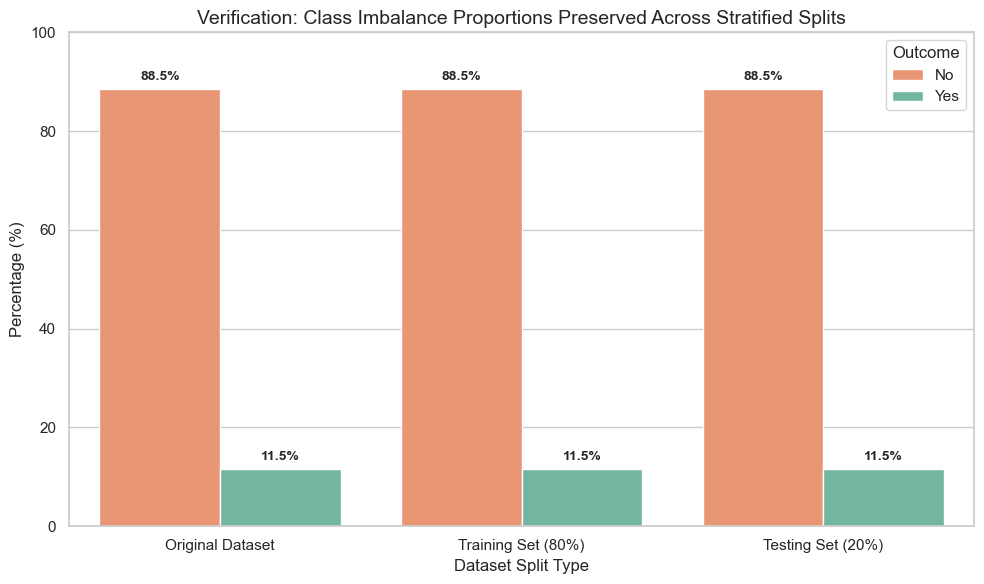

In [38]:
# --- Step 9: Visualize the Stratified Split Proportions ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate normalized percentages for each set
orig_pct = y.value_counts(normalize=True) * 100
train_pct = y_train.value_counts(normalize=True) * 100
test_pct = y_test.value_counts(normalize=True) * 100

# 2. Combine the data into a clean DataFrame for plotting
plot_df = pd.DataFrame({
    'Outcome': ['No', 'Yes', 'No', 'Yes', 'No', 'Yes'],
    'Percentage': [orig_pct['no'], orig_pct['yes'], 
                   train_pct['no'], train_pct['yes'], 
                   test_pct['no'], test_pct['yes']],
    'Dataset Split': ['Original Dataset', 'Original Dataset', 
                     'Training Set (80%)', 'Training Set (80%)', 
                     'Testing Set (20%)', 'Testing Set (20%)']
})

# 3. Render the bar chart using explicit, safe hex colors to prevent version bugs
plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df, 
    x='Dataset Split', 
    y='Percentage', 
    hue='Outcome', 
    palette=['#fc8d62', '#66c2a5']  # Hardcoded safe colors for No and Yes
)

plt.title('Verification: Class Imbalance Proportions Preserved Across Stratified Splits', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xlabel('Dataset Split Type')
plt.ylim(0, 100)

# Add text labels on top of the bars showing the exact percentages
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:  # Only label visible bars
        plt.gca().annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [39]:
# --- Step 10: Encode Text Columns ---
import pandas as pd

# We use pd.get_dummies to convert categorical features into numeric dummy columns
# drop_first=True helps reduce unnecessary columns (multicollinearity)
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Make sure both train and test have identical columns after encoding
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print(f"Data successfully encoded!")
print(f"Features expanded from {X_train.shape[1]} columns to {X_train_encoded.shape[1]} numeric columns.")

Data successfully encoded!
Features expanded from 16 columns to 3292 numeric columns.


In [40]:
# --- Step 11: Initialize and Fit the Model ---
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=5,                 # Prunes tree depth to keep it from overfitting
    class_weight='balanced',     # Penalizes misclassifications on the rare 'yes' class heavily
    random_state=42
)

# Train the model on our stratified training features and targets
dt_model.fit(X_train_encoded, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


--- Evaluation Metrics (Classification Report) ---
              precision    recall  f1-score   support

          no       0.95      0.42      0.59       801
         yes       0.16      0.85      0.27       104

    accuracy                           0.47       905
   macro avg       0.56      0.63      0.43       905
weighted avg       0.86      0.47      0.55       905



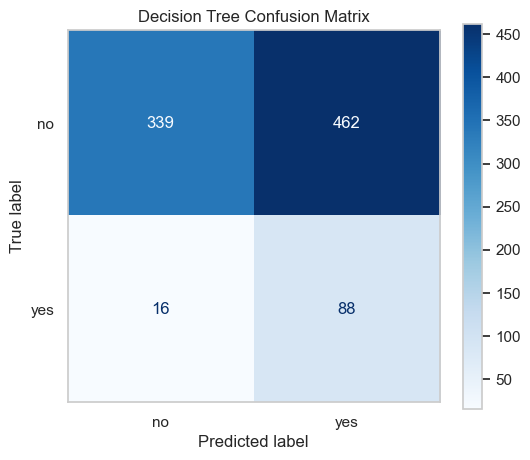

In [41]:
# --- Step 12: Predict and Evaluate Performance ---
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions on the unseen testing data
y_pred = dt_model.predict(X_test_encoded)

# 1. Print Text-based Metrics
print("--- Evaluation Metrics (Classification Report) ---")
print(classification_report(y_test, y_pred))

# 2. Plot Visual Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=dt_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_model.classes_)

# Draw the plot
disp.plot(cmap='Blues', ax=plt.gca(), values_format='d')
plt.title("Decision Tree Confusion Matrix")
plt.grid(False) # Turn off background grid lines for clarity
plt.show()

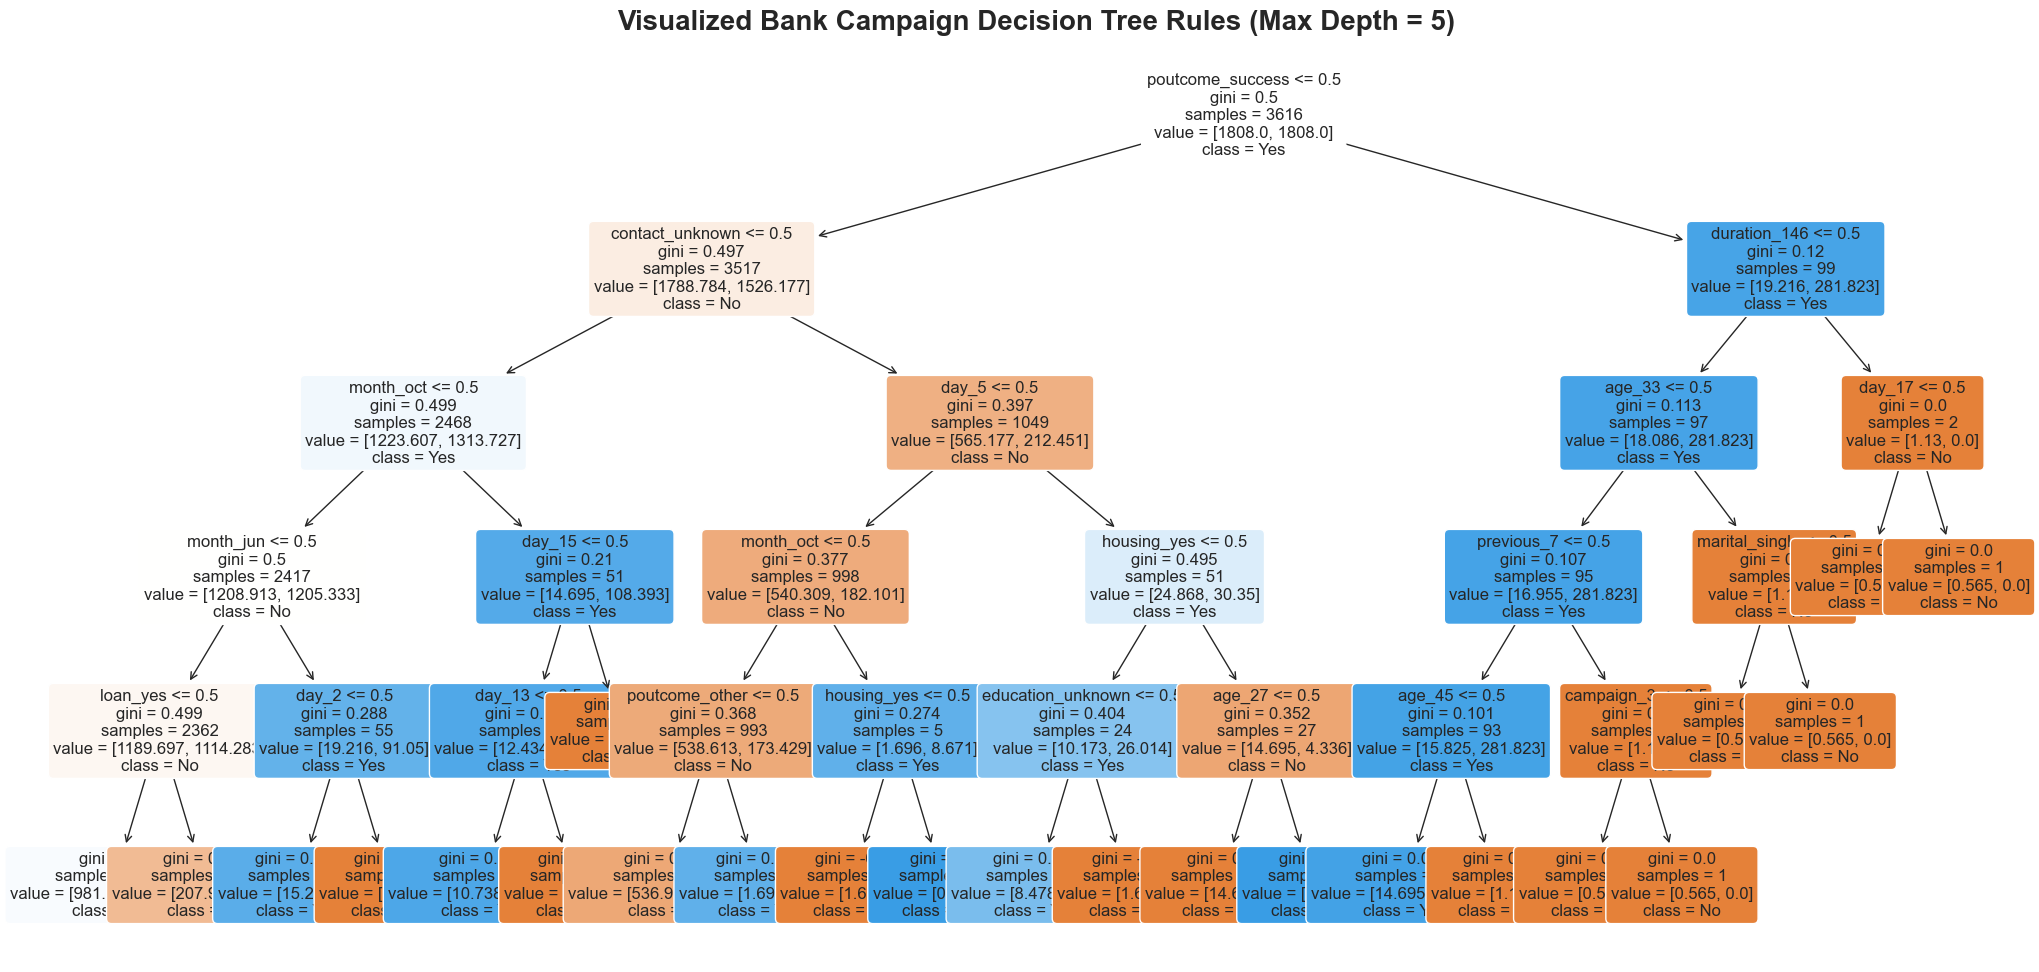

In [42]:
# --- Step 13: Visualize the Decision Tree ---
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Set up a large frame size so the text inside the tree nodes is readable
plt.figure(figsize=(25, 12))

# Plot the tree layout
plot_tree(
    dt_model, 
    feature_names=X_train_encoded.columns,  # Shows actual variable names at split points
    class_names=['No', 'Yes'],              # Shows the prediction output target names
    filled=True,                            # Colors nodes based on class purity (blue vs orange)
    rounded=True,                           # Makes node boxes look clean with rounded corners
    fontsize=12                             # Ensures node text size is legible
)

plt.title("Visualized Bank Campaign Decision Tree Rules (Max Depth = 5)", fontsize=20, fontweight='bold')
plt.show()